In [1]:
begin
    using Pkg
    dev_folder = joinpath(@__DIR__, "../Examples")
    Pkg.activate(dev_folder)
end
Threads.nthreads()

  Activating project at `~/Realizibility_index/BindingAndCatalysis.jl/Examples`


24

In [2]:
using Polyhedra
using SparseArrays
using GLMakie # for plotting, we use Makie backend, could also be GLMakie or WGLMakie...


In [3]:
using Revise
using BindingAndCatalysis # import the package

[ Info: Precompiling BindingAndCatalysis [b532a4b1-2c45-4c12-bcaf-8695372aa40c] (cache misses: include_dependency fsize change (2), wrong dep version loaded (2), incompatible header (4))


In [6]:
model = let
    N = [2 0 -1 0; 
        0 1 1 -1]
    L = [1 0 2 2
        0 1 0 1]
    x_sym = [:P,:D, :P₂, :C]
    q_sym = [:tP, :tD]
    K_sym = [:KP, :KD]
    md = Bnc(N = N, L = L, x_sym=x_sym, q_sym=q_sym, K_sym=K_sym)

    k_cat_sym = [:β, :γP, :γP₂]
    update_catalysis!(md; Π = [0 0 0 1; 1 0 0 0; 0 0 1 0], Γ = [1 -1 2], k_sym= k_cat_sym)
    md
end

[ Info: q_cat is not picked, the catalysis will involve the first r_v q by default
[ Info: q is reordered to make catalysis-involving species first


----------Binding Network Summary:-------------
Number of species (n): 4
Number of conserved quantities (d): 2
Number of reactions (r): 2
L matrix: sparse([1, 2, 1, 1, 2], [1, 2, 3, 4, 4], [1, 1, 2, 2, 1], 2, 4)
N matrix: sparse([1, 2, 1, 2, 2], [1, 2, 3, 3, 4], [2, 1, -1, 1, -1], 2, 4)
Direction of binding reactions: forward
Catalysis involved: Yes
Regimes constructed: No
-----------------------------------------------

In [7]:
find_all_regimes!(model)

[ Info: ---------------------Start finding all regimes--------------------
[ Info: Finished, with 6 regimes found and 6 asymptotic regimes.
[ Info: 2.Building x-neighbor regime graph...
[ Info: 3.Building regime objects...
[ Info: 4.Propagating affine data and deferred nullity labels...
[ Info: Calculating vertices neighbor graph with qK change dir
[ Info: Finished.


In [8]:
f, ax = draw_graph(model)

[ Info: Number of polyhedra to calc volume: 5
[ Info: All regimes converged after 3000000 samples.


(Scene(1 children, 0 plots), Axis (2 plots), Plot{GraphMakie.graphplot, Tuple{Graphs.SimpleGraphs.SimpleDiGraph{Int64}}})

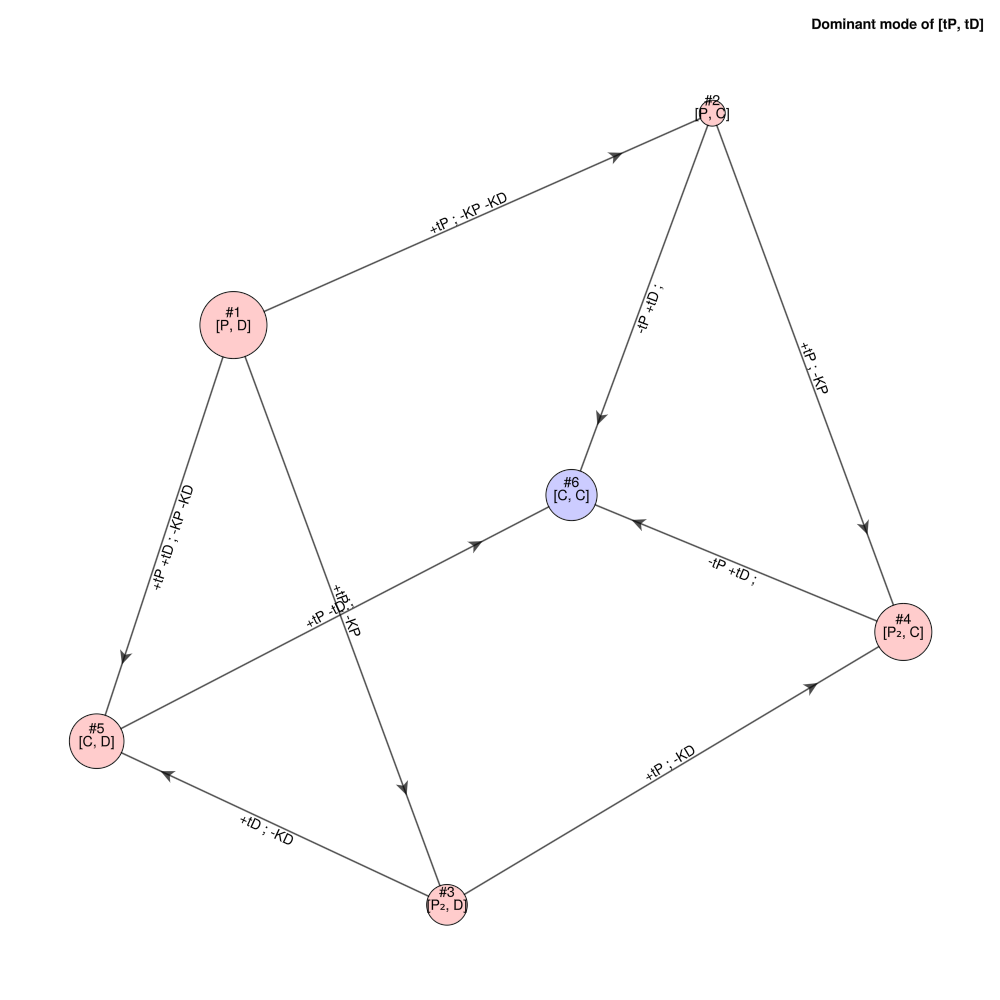

In [9]:
f

In [10]:
siso1 = SISOPaths(model, :tP)

[ Info: sources: [1]
[ Info: sinks: [4]
[ Info: Start enumerating paths from sources to sinks. This may take a while if there are many paths.
[ Info: Total vertices to process in topological order: 6
[ Info: Finished enumerating paths. Now collecting paths from sources. Total sources: 1


SISOPaths{Int64}(Bnc{Int64}(sparse([1, 2, 1, 2, 2], [1, 2, 3, 3, 4], [2, 1, -1, 1, -1], 2, 4), sparse([1, 2, 1, 1, 2], [1, 2, 3, 4, 4], [1, 1, 2, 2, 1], 2, 4), 2, 4, 2, Symbolics.Num[P, D, P₂, C], Symbolics.Num[tP, tD], Symbolics.Num[KP, KD], BindingAndCatalysis.CatalysisData(Bnc{Int64}(#= circular reference @-2 =#), sparse([1, 1, 1], [1, 2, 3], [1, -1, 2], 1, 3), sparse([2, 3, 1], [1, 3, 4], [1, 1, 1], 3, 4), sparse([1, 1, 1], [1, 2, 3], [1, -1, 2], 1, 3), sparse(Int64[], Int64[], Int64[], 1, 0), 1, 3, 0, 1, Symbolics.Num[β, γP, γP₂], sparse([1, 1, 1], [1, 2, 3], [1.0, -1.0, 2.0], 1, 3), sparse([2, 3, 1], [1, 3, 4], [1.0, 1.0, 1.0], 3, 4), sparse([1, 2, 1], [1, 2, 3], [1, 1, 2], 2, 3), BindingAndCatalysis.MatrixHelper{Int64}(3, [[1, 3], [2]], [[1, 0, 2], [0, 1, 0]], [[0.0, 0.3010299956639812], [0.0]], [1, 2, 2], 1, Vector{Vector{BindingAndCatalysis.ChoiceIneq}}[[[BindingAndCatalysis.ChoiceIneq(1, 1)], [BindingAndCatalysis.ChoiceIneq(1, -1)]], [[]]], BindingAndCatalysis.Hyperplane_perm

In [11]:
f,ax = draw_graph(siso1)

(Scene(1 children, 0 plots), Axis (2 plots), Plot{GraphMakie.graphplot, Tuple{Graphs.SimpleGraphs.SimpleDiGraph{Int64}}})

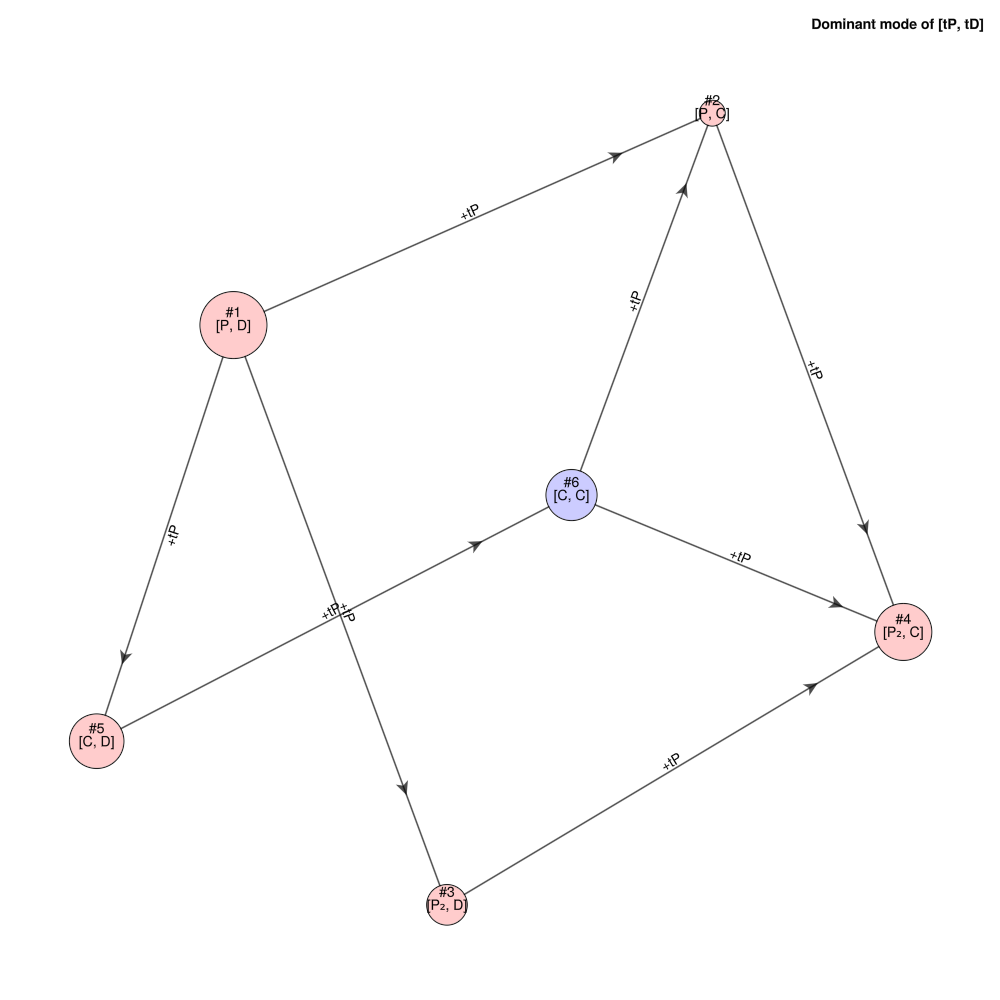

In [12]:
f

In [20]:
summary(siso1)

Path 1         #1 → #2 → #4            Volume: 0.2501 ± 0.0012
Path 2         #1 → #3 → #4            Volume: 0.3323 ± 0.0015
Path 3         #1 → #5 → #6 → #2 → #4  Volume: 0.0834 ± 0.0004
Path 4         #1 → #5 → #6 → #4       Volume: 0.3341 ± 0.0015


In [13]:
# save("./regime_graph.png", f)

In [19]:
model = let
    L = [1 0 0 1
        0 1 1 1]
    Bnc(L=L)
end

----------Binding Network Summary:-------------
Number of species (n): 4
Number of conserved quantities (d): 2
Number of reactions (r): 2
L matrix: sparse([1, 2, 2, 1, 2], [1, 2, 3, 4, 4], [1, 1, 1, 1, 1], 2, 4)
N matrix: sparse([2, 1, 2, 1, 2], [1, 2, 2, 3, 4], [1, 1, 1, -1, -1], 2, 4)
Direction of binding reactions: forward
Catalysis involved: No
Regimes constructed: No
-----------------------------------------------

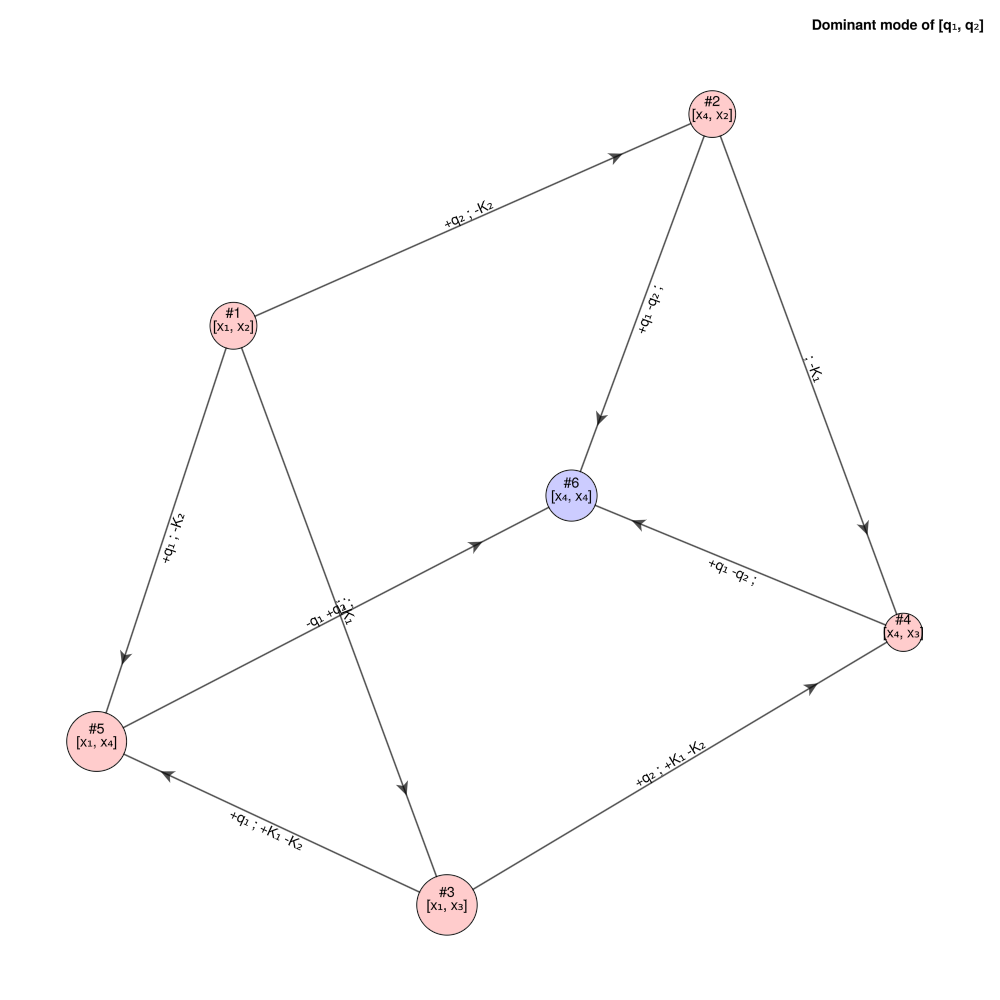

In [107]:
f,ax = draw_graph(model)
f

In [102]:
using BindingAndCatalysis.CDDLib

In [108]:
p1 = get_polyhedron(model,2)
p2 = get_polyhedron(model,4)
p3 = get_polyhedron(model,5)


p6 = get_polyhedron(model,6)

Polyhedron CDDLib.Polyhedron{Float64}:
1-element iterator of HyperPlane{Float64, Vector{Float64}}:
 HyperPlane([1.0, -1.0, -0.0, -0.0], 0.0),
3-element iterator of HalfSpace{Float64, Vector{Float64}}:
 HalfSpace([-1.0, -0.0, -1.0, 1.0], 0.0)
 HalfSpace([-1.0, -0.0, -0.0, 1.0], 0.0)
 HalfSpace([-0.0, -0.0, -0.0, -0.0], 1.0)

In [109]:
(hps,infos) = polyhedra_to_hyperplane_pool([p1,p2,p3,p6])

([([0.0, 1.0, 0.0, -1.0], 0.0), ([0.0, 0.0, 1.0, 0.0], 0.0), ([1.0, -1.0, -0.0, -0.0], -0.0), ([0.0, 1.0, 1.0, -1.0], 0.0), ([1.0, 0.0, 0.0, -1.0], 0.0), ([1.0, 0.0, 1.0, -1.0], 0.0), ([0.0, 0.0, 0.0, 0.0], 1.0)], Tuple{Vector{Int64}, Vector{Int8}}[([1, 2, 3], [1, 1, -1]), ([4, 2, 3], [1, -1, -1]), ([3, 5, 6], [1, 1, 1]), ([3, 6, 5, 7], [0, 1, 1, 1])])

In [110]:
hps

7-element Vector{Tuple{Vector{Float64}, Float64}}:
 ([0.0, 1.0, 0.0, -1.0], 0.0)
 ([0.0, 0.0, 1.0, 0.0], 0.0)
 ([1.0, -1.0, -0.0, -0.0], -0.0)
 ([0.0, 1.0, 1.0, -1.0], 0.0)
 ([1.0, 0.0, 0.0, -1.0], 0.0)
 ([1.0, 0.0, 1.0, -1.0], 0.0)
 ([0.0, 0.0, 0.0, 0.0], 1.0)

In [111]:
display.(infos)

([1, 2, 3], Int8[1, 1, -1])

([4, 2, 3], Int8[1, -1, -1])

([3, 5, 6], Int8[1, 1, 1])

([3, 6, 5, 7], Int8[0, 1, 1, 1])

4-element Vector{Nothing}:
 nothing
 nothing
 nothing
 nothing

In [112]:
ins12 = intersect_polyinfo(infos[1:2])

([1, 2, 3, 4], Int8[1, 0, -1, 1])

In [113]:
ins12_nohp =  remove_hyperplane(ins12)

([1, 3, 4], Int8[1, -1, 1])

In [114]:
infos[3]

([3, 5, 6], Int8[1, 1, 1])

In [115]:
p123 = intersect_polyinfo(ins12_nohp, infos[3])

([1, 3, 4, 5, 6], Int8[1, 0, 1, 1, 1])

In [116]:
poly123 = hyperplane_pool_to_polyhedron(hps, p123...)

Polyhedron CDDLib.Polyhedron{Float64}:
1-element iterator of HyperPlane{Float64, Vector{Float64}}:
 HyperPlane([-1.0, 1.0, 0.0, 0.0], -0.0),
4-element iterator of HalfSpace{Float64, Vector{Float64}}:
 HalfSpace([-0.0, -1.0, -0.0, 1.0], 0.0)
 HalfSpace([-0.0, -1.0, -1.0, 1.0], 0.0)
 HalfSpace([-1.0, -0.0, -0.0, 1.0], 0.0)
 HalfSpace([-1.0, -0.0, -1.0, 1.0], 0.0)

In [117]:
same_polyhedron(poly123, p6)

true

In [118]:
model = let 
    N = [1 1 -1 0
         1 0 1 -1]
    Bnc(N=N)
end

----------Binding Network Summary:-------------
Number of species (n): 4
Number of conserved quantities (d): 2
Number of reactions (r): 2
L matrix: sparse([1, 2, 1, 2, 1, 2], [1, 2, 3, 3, 4, 4], [1, 1, 1, 1, 2, 1], 2, 4)
N matrix: sparse([1, 2, 1, 1, 2, 2], [1, 1, 2, 3, 3, 4], [1, 1, 1, -1, 1, -1], 2, 4)
Direction of binding reactions: forward
Catalysis involved: No
Regimes constructed: No
-----------------------------------------------

[ Info: ---------------------Start finding all regimes--------------------
[ Info: Finished, with 8 regimes found and 7 asymptotic regimes.
[ Info: 2.Building x-neighbor regime graph...
[ Info: 3.Building regime objects...
[ Info: 4.Propagating affine data and deferred nullity labels...
[ Info: Calculating vertices neighbor graph with qK change dir
[ Info: Finished.
[ Info: Number of polyhedra to calc volume: 5
[ Info: All regimes converged after 2400000 samples.


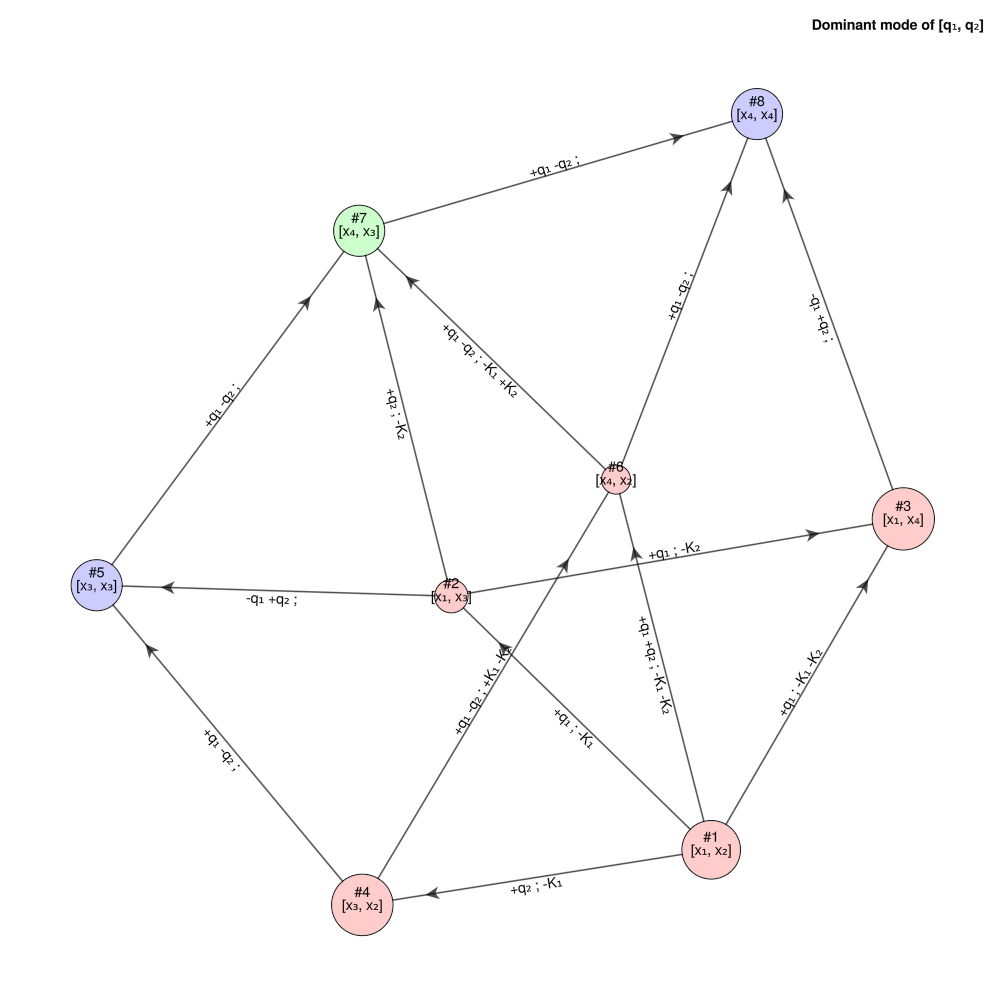

In [119]:
f,ax = draw_graph(model)
f

In [120]:
poly7 = get_polyhedron(model, 7)
poly2 = get_polyhedron(model, 2)
poly6 = get_polyhedron(model, 6)
poly3 = get_polyhedron(model, 3)

Polyhedron CDDLib.Polyhedron{Float64}:
4-element iterator of HalfSpace{Float64, Vector{Float64}}:
 HalfSpace([-2.0, 1.0, -0.0, 1.0], 0.0)
 HalfSpace([-1.0, 1.0, -0.0, -0.0], -0.3010299956639812)
 HalfSpace([-2.0, -0.0, 1.0, 1.0], 0.0)
 HalfSpace([-1.0, -0.0, -0.0, 1.0], 0.0)

In [121]:
(hps,infos) = polyhedra_to_hyperplane_pool([poly7, poly2, poly6, poly3])

([([0.0, 1.0, 0.0, -1.0], 0.3010299956639812), ([1.0, -1.0, 0.0, 0.0], 0.0), ([1.0, -1.0, -1.0, 1.0], -0.3010299956639812), ([1.0, -1.0, -0.0, -0.0], -0.3010299956639812), ([1.0, 0.0, -1.0, 0.0], 0.0), ([1.0, -0.0, -0.0, -1.0], -0.0), ([1.0, 1.0, -1.0, -1.0], 0.3010299956639812), ([1.0, -1.0, 1.0, -1.0], 0.3010299956639812), ([1.0, -0.5, 0.0, -0.5], 0.0), ([1.0, 0.0, -0.5, -0.5], 0.0)], Tuple{Vector{Int64}, Vector{Int8}}[([1, 2, 3, 4], [1, 1, 1, -1]), ([2, 1, 5, 6], [1, -1, 1, -1]), ([7, 8, 3, 4], [1, 1, -1, -1]), ([9, 4, 10, 6], [1, 1, 1, 1])])

In [122]:
hps

10-element Vector{Tuple{Vector{Float64}, Float64}}:
 ([0.0, 1.0, 0.0, -1.0], 0.3010299956639812)
 ([1.0, -1.0, 0.0, 0.0], 0.0)
 ([1.0, -1.0, -1.0, 1.0], -0.3010299956639812)
 ([1.0, -1.0, -0.0, -0.0], -0.3010299956639812)
 ([1.0, 0.0, -1.0, 0.0], 0.0)
 ([1.0, -0.0, -0.0, -1.0], -0.0)
 ([1.0, 1.0, -1.0, -1.0], 0.3010299956639812)
 ([1.0, -1.0, 1.0, -1.0], 0.3010299956639812)
 ([1.0, -0.5, 0.0, -0.5], 0.0)
 ([1.0, 0.0, -0.5, -0.5], 0.0)

In [67]:
f(i)= let
    C,C0,nulliy = get_C_C0_nullity(model,i)
    get_polyhedron(hcat(C0,C), zeros(size(C0)), nulliy)
end

f (generic function with 1 method)

In [68]:
g(i) = let
    C,C0 = get_C_C0_x(model,i)
    get_polyhedron(hcat(C0,C), zeros(size(C0)))
end

g (generic function with 1 method)

In [69]:
vrep(g(1))

[ Info: ---------------------Start finding all vertices--------------------
[ Info: Finished, with 66 vertices found and 66 asymptotic vertices.
[ Info: -------------Start calculating nullity for each vertex, it also takes a while.------------
[ Info: 1.Building Nρ_inv cache in parallel...
[ Info: 2.Calculating nullity for each vertex in parallel...


V-representation CDDLib.CDDGeneratorMatrix{Float64, Float64}:
1-element iterator of Vector{Float64}:
 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
2-element iterator of Line{Float64, Vector{Float64}}:
 Line([1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
 Line([0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]),
9-element iterator of Ray{Float64, Vector{Float64}}:
 Ray([0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -1.0, 0.0])
 Ray([0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
 Ray([0.0, 0.0, 0.0, 0.0, 0.0, 0.0, -1.0, 0.0, 0.0])
 Ray([0.0, -1.0, 0.0, 0.0, 0.0, 0.0, -1.0, -1.0, 0.0])
 Ray([0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0])
 Ray([0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0])
 Ray([0.0, 0.0, 0.0, 0.0, 0.0, -1.0, 0.0, 0.0, 0.0])
 Ray([0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0])
 Ray([0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0])

In [70]:
vrep(g(2))

V-representation CDDLib.CDDGeneratorMatrix{Float64, Float64}:
1-element iterator of Vector{Float64}:
 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
2-element iterator of Line{Float64, Vector{Float64}}:
 Line([1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
 Line([0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]),
9-element iterator of Ray{Float64, Vector{Float64}}:
 Ray([0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -1.0, 0.0])
 Ray([0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
 Ray([0.0, 0.0, 0.0, 0.0, 0.0, 0.0, -1.0, 0.0, 0.0])
 Ray([0.0, -1.0, 0.0, 0.0, 0.0, 0.0, -1.0, -1.0, 0.0])
 Ray([0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0])
 Ray([0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0])
 Ray([0.0, 0.0, 0.0, 0.0, 0.0, -1.0, 0.0, 0.0, 0.0])
 Ray([0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0])
 Ray([0.0, 0.0, 0.0, -1.0, 0.0, 0.0, 0.0, 0.0, 0.0])

In [55]:
vrep(f(1))

[ Info: ---------------------Start finding all vertices--------------------
[ Info: Finished, with 4 vertices found and 4 asymptotic vertices.
[ Info: -------------Start calculating nullity for each vertex, it also takes a while.------------
[ Info: 1.Building Nρ_inv cache in parallel...
[ Info: 2.Calculating nullity for each vertex in parallel...


V-representation CDDLib.CDDGeneratorMatrix{Float64, Float64}:
1-element iterator of Vector{Float64}:
 [0.0, 0.0, 0.0, 0.0],
2-element iterator of Line{Float64, Vector{Float64}}:
 Line([1.0, 0.0, 0.0, 0.0])
 Line([0.0, 1.0, 1.0, 1.0]),
2-element iterator of Ray{Float64, Vector{Float64}}:
 Ray([0.0, -1.0, 0.0, 0.0])
 Ray([0.0, -0.0, -1.0, 0.0])

In [56]:
vrep(f(2))

V-representation CDDLib.CDDGeneratorMatrix{Float64, Float64}:
1-element iterator of Vector{Float64}:
 [0.0, 0.0, 0.0, 0.0],
2-element iterator of Line{Float64, Vector{Float64}}:
 Line([1.0, 0.0, 0.0, 0.0])
 Line([0.0, 1.0, 1.0, 1.0]),
2-element iterator of Ray{Float64, Vector{Float64}}:
 Ray([0.0, 0.0, -1.0, 0.0])
 Ray([0.0, 1.0, 1.0, 0.0])

In [57]:
vrep(f(3))

V-representation CDDLib.CDDGeneratorMatrix{Float64, Float64}:
1-element iterator of Vector{Float64}:
 [0.0, 0.0, 0.0, 0.0],
2-element iterator of Line{Float64, Vector{Float64}}:
 Line([1.0, 0.0, 0.0, 0.0])
 Line([0.0, 1.0, 1.0, 1.0]),
2-element iterator of Ray{Float64, Vector{Float64}}:
 Ray([0.0, -1.0, -0.0, 0.0])
 Ray([0.0, 1.0, 1.0, 0.0])

In [58]:
vrep(f(4))

V-representation CDDLib.CDDGeneratorMatrix{Float64, Float64}:
1-element iterator of Vector{Float64}:
 [0.0, 0.0, 0.0, 0.0],
1-element iterator of Line{Float64, Vector{Float64}}:
 Line([0.0, 1.0, 1.0, 1.0]),
2-element iterator of Ray{Float64, Vector{Float64}}:
 Ray([1.0, 0.0, 0.0, 0.0])
 Ray([0.0, 1.0, 1.0, 0.0])

In [59]:
vrep(f(5))

LoadError: BoundsError: attempt to access 4-element BitVector at index [5]

In [23]:
dim(f(1))

9

In [124]:
a =  compile_regime_catalog(L)

RegimeCatalog{Int64}(8, 16, [[1, 9, 10, 11, 12, 13, 14, 15, 16], [2, 9, 10, 11, 12, 13, 14, 15, 16], [3, 16], [4, 14], [5, 12, 14, 15], [6, 15], [7, 10, 13], [8, 11, 13, 14, 15, 16]], [[1, 0, 0, 0, 0, 0, 0, 0, 2, 3, 4, 5, 6, 7, 8, 9], [0, 1, 0, 0, 0, 0, 0, 0, 2, 3, 4, 5, 6, 7, 8, 9], [0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2], [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0], [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 2, 0, 3, 4, 0], [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0], [0, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0, 0, 3, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0, 3, 4, 5, 6]], [[0.0, 0.0, 0.0, 1.0986122886681098, 0.0, 1.6094379124341003, 1.3862943611198906, 1.3862943611198906, 1.9459101490553132], [0.0, 0.6931471805599453, 0.6931471805599453, 0.6931471805599453, 0.0, 1.791759469228055, 0.6931471805599453, 0.6931471805599453, 1.9459101490553132], [0.0, 0.0], [0.0, 0.0], [0.0, 0.6931471805599453, 0.6931471805599453, 0.0], [0.0, 0.0], [0.0, 0.6931471805599453, 1.3862943611198906], [0.0,

In [168]:
@btime find_all_vertices(L;asymptotic=false)

  797.338 ms (16357311 allocations: 422.62 MiB)


56243-element Vector{Vector{Int8}}:
 [1, 2, 3, 4, 5, 6, 7, 8]
 [1, 2, 3, 4, 5, 6, 13, 8]
 [1, 2, 3, 4, 5, 6, 14, 8]
 [1, 2, 3, 4, 5, 6, 15, 8]
 [1, 12, 3, 4, 5, 6, 7, 8]
 [1, 12, 3, 4, 5, 6, 13, 8]
 [1, 12, 3, 4, 5, 6, 14, 8]
 [1, 12, 3, 4, 5, 6, 15, 8]
 [1, 15, 3, 4, 5, 6, 7, 8]
 [1, 15, 3, 4, 5, 6, 13, 8]
 [1, 15, 3, 4, 5, 6, 14, 8]
 [1, 15, 3, 4, 5, 6, 15, 8]
 [1, 16, 3, 4, 5, 6, 7, 8]
 ⋮
 [16, 2, 16, 16, 15, 6, 7, 16]
 [16, 2, 16, 16, 15, 6, 15, 16]
 [16, 16, 16, 16, 15, 6, 7, 16]
 [16, 16, 16, 16, 15, 6, 15, 16]
 [16, 2, 16, 16, 15, 15, 7, 8]
 [16, 2, 16, 16, 15, 15, 15, 8]
 [16, 16, 16, 16, 15, 15, 7, 8]
 [16, 16, 16, 16, 15, 15, 15, 8]
 [16, 2, 16, 16, 15, 15, 7, 16]
 [16, 2, 16, 16, 15, 15, 15, 16]
 [16, 16, 16, 16, 15, 15, 7, 16]
 [16, 16, 16, 16, 15, 15, 15, 16]

In [166]:
@btime nonasymptotic_perms(compile_regime_catalog(L))

  60.386 ms (977905 allocations: 83.61 MiB)


56243-element Vector{Vector{Int64}}:
 [1, 2, 3, 4, 5, 6, 7, 8]
 [1, 2, 3, 4, 5, 6, 13, 8]
 [1, 2, 3, 4, 5, 6, 14, 8]
 [1, 2, 3, 4, 5, 6, 15, 8]
 [1, 12, 3, 4, 5, 6, 7, 8]
 [1, 12, 3, 4, 5, 6, 13, 8]
 [1, 12, 3, 4, 5, 6, 14, 8]
 [1, 12, 3, 4, 5, 6, 15, 8]
 [1, 15, 3, 4, 5, 6, 7, 8]
 [1, 15, 3, 4, 5, 6, 13, 8]
 [1, 15, 3, 4, 5, 6, 14, 8]
 [1, 15, 3, 4, 5, 6, 15, 8]
 [1, 16, 3, 4, 5, 6, 7, 8]
 ⋮
 [16, 2, 16, 16, 15, 6, 7, 16]
 [16, 2, 16, 16, 15, 6, 15, 16]
 [16, 16, 16, 16, 15, 6, 7, 16]
 [16, 16, 16, 16, 15, 6, 15, 16]
 [16, 2, 16, 16, 15, 15, 7, 8]
 [16, 2, 16, 16, 15, 15, 15, 8]
 [16, 16, 16, 16, 15, 15, 7, 8]
 [16, 16, 16, 16, 15, 15, 15, 8]
 [16, 2, 16, 16, 15, 15, 7, 16]
 [16, 2, 16, 16, 15, 15, 15, 16]
 [16, 16, 16, 16, 15, 15, 7, 16]
 [16, 16, 16, 16, 15, 15, 15, 16]

In [179]:
@btime feasible_perms(compile_regime_catalog(L))

  97.066 ms (2105109 allocations: 156.03 MiB)


56243-element Vector{Vector{Int8}}:
 [1, 2, 3, 4, 5, 6, 7, 8]
 [1, 2, 3, 4, 5, 6, 13, 8]
 [1, 2, 3, 4, 5, 6, 14, 8]
 [1, 2, 3, 4, 5, 6, 15, 8]
 [1, 12, 3, 4, 5, 6, 7, 8]
 [1, 12, 3, 4, 5, 6, 13, 8]
 [1, 12, 3, 4, 5, 6, 14, 8]
 [1, 12, 3, 4, 5, 6, 15, 8]
 [1, 15, 3, 4, 5, 6, 7, 8]
 [1, 15, 3, 4, 5, 6, 13, 8]
 [1, 15, 3, 4, 5, 6, 14, 8]
 [1, 15, 3, 4, 5, 6, 15, 8]
 [1, 16, 3, 4, 5, 6, 7, 8]
 ⋮
 [16, 2, 16, 16, 15, 6, 7, 16]
 [16, 2, 16, 16, 15, 6, 15, 16]
 [16, 16, 16, 16, 15, 6, 7, 16]
 [16, 16, 16, 16, 15, 6, 15, 16]
 [16, 2, 16, 16, 15, 15, 7, 8]
 [16, 2, 16, 16, 15, 15, 15, 8]
 [16, 16, 16, 16, 15, 15, 7, 8]
 [16, 16, 16, 16, 15, 15, 15, 8]
 [16, 2, 16, 16, 15, 15, 7, 16]
 [16, 2, 16, 16, 15, 15, 15, 16]
 [16, 16, 16, 16, 15, 15, 7, 16]
 [16, 16, 16, 16, 15, 15, 15, 16]

In [193]:
a = get_M(model,1)

8×8 SparseMatrixCSC{Int64, Int64} with 16 stored entries:
 1  ⋅  ⋅  ⋅   ⋅   ⋅   ⋅   ⋅
 ⋅  1  ⋅  ⋅   ⋅   ⋅   ⋅   ⋅
 ⋅  ⋅  1  ⋅   ⋅   ⋅   ⋅   ⋅
 ⋅  ⋅  ⋅  1   ⋅   ⋅   ⋅   ⋅
 ⋅  1  ⋅  1  -1   ⋅   ⋅   ⋅
 1  1  ⋅  ⋅   ⋅  -1   ⋅   ⋅
 1  1  ⋅  ⋅   ⋅   ⋅  -1   ⋅
 ⋅  ⋅  1  ⋅   1   ⋅   ⋅  -1

In [194]:
inv(a)

LoadError: AssertionError: Tv == Float64 || Tv == ComplexF64

In [99]:
# A hyperplane is stored as (c, c0), meaning dot(c, x) + c0 = 0.
# In the returned sign vector:
#   sign = +1  means the polyhedron uses   dot(c, x) + c0 >= 0
#   sign = -1  means the polyhedron uses -(dot(c, x) + c0) >= 0
#   sign = 0   means this hyperplane is an equality constraint

function _canonicalize_hyperplane(c::AbstractVector{<:Real}, c0::Real; atol::Real = 1e-10)
    ccanon = Float64.(collect(c))
    c0canon = Float64(c0)

    scale = maximum(abs, vcat(ccanon, c0canon))
    scale <= atol && error("Encountered a degenerate hyperplane with all coefficients near zero.")

    ccanon ./= scale
    c0canon /= scale

    s = Int8(1)
    pivot = findfirst(x -> abs(x) > atol, ccanon)
    if isnothing(pivot)
        if c0canon < -atol
            ccanon .*= -1
            c0canon *= -1
            s = Int8(-1)
        end
    elseif ccanon[pivot] < 0
        ccanon .*= -1
        c0canon *= -1
        s = Int8(-1)
    end

    q(x) = round(Int, x / atol)
    key = Tuple(vcat(q.(ccanon), q(c0canon)))
    return ccanon, c0canon, s, key
end

function polyhedra_to_hyperplane_pool(polys::AbstractVector{<:Polyhedron}; atol::Real = 1e-10)
    hyperplanes = Tuple{Vector{Float64}, Float64}[]
    key_to_idx = Dict{Tuple, Int}()
    poly_info = Vector{Tuple{Vector{Int}, Vector{Int8}}}(undef, length(polys))

    for (poly_i, poly) in pairs(polys)
        C, C0, nullity = get_C_C0_nullity(poly)
        idxs = Int[]
        signs = Int8[]

        for row in axes(C, 1)
            ccanon, c0canon, s, key = _canonicalize_hyperplane(vec(C[row, :]), C0[row]; atol = atol)
            hid = get(key_to_idx, key, 0)
            if hid == 0
                push!(hyperplanes, (ccanon, c0canon))
                hid = length(hyperplanes)
                key_to_idx[key] = hid
            end

            push!(idxs, hid)
            push!(signs, row <= nullity ? Int8(0) : s)
        end

        poly_info[poly_i] = (idxs, signs)
    end

    return hyperplanes, poly_info
end

function hyperplane_pool_to_polyhedron(
    hyperplanes::AbstractVector{<:Tuple},
    hp_idxs::AbstractVector{<:Integer},
    hp_signs::AbstractVector{<:Integer},
)
    length(hp_idxs) == length(hp_signs) || error("hp_idxs and hp_signs must have the same length.")
    isempty(hyperplanes) && error("hyperplanes cannot be empty.")

    n = length(first(hyperplanes)[1])
    m = length(hp_idxs)
    C = Matrix{Float64}(undef, m, n)
    C0 = Vector{Float64}(undef, m)
    linset = BitSet()

    for i in eachindex(hp_idxs)
        c, c0 = hyperplanes[hp_idxs[i]]
        s = Int8(hp_signs[i])

        if s == 0
            C[i, :] .= c
            C0[i] = c0
            push!(linset, i)
        elseif s > 0
            C[i, :] .= c
            C0[i] = c0
        else
            C[i, :] .= -c
            C0[i] = -c0
        end
    end

    return polyhedron(hrep(-C, C0, linset), CDDLib.Library())
end

rebuild_polyhedra(
    hyperplanes::AbstractVector{<:Tuple},
    poly_info::AbstractVector{<:Tuple},
) = [hyperplane_pool_to_polyhedron(hyperplanes, idxs, signs) for (idxs, signs) in poly_info]

# Example:
# polys = [p2, p3, p6]
# all_hyperplanes, poly_info = polyhedra_to_hyperplane_pool(polys)
# polys_rebuilt = rebuild_polyhedra(all_hyperplanes, poly_info)
# same_polyhedron(polys[1], polys_rebuilt[1])

rebuild_polyhedra (generic function with 1 method)

In [ ]:
"""
    intersect_polyinfo(polyinfos...)

输入多个 `poly_info`，每个元素格式是 `(hp_idxs, hp_signs)`。

规则：
1. 收集所有出现过的 `hp_idx`，去重后全部保留
2. 对每个 `hp_idx`，汇总所有 poly_info 里出现过的 sign：
   - 如果包含 `0`，输出 `0`
   - 如果同时包含 `1` 和 `-1`，输出 `0`
   - 否则输出唯一那个非零 sign

返回 `(all_idxs, merged_signs)`
"""
function intersect_polyinfo(polyinfos...)
    isempty(polyinfos) && error("Need at least one poly_info.")

    infos = collect(polyinfos)

    all_idxs = Int[]
    seen = Set{Int}()

    for (hp_idxs, _) in infos
        for idx in hp_idxs
            idx = Int(idx)
            if !(idx in seen)
                push!(all_idxs, idx)
                push!(seen, idx)
            end
        end
    end

    merged_signs = Int8[]

    for idx in all_idxs
        signs_here = Set{Int8}()

        for (hp_idxs, hp_signs) in infos
            for (j, s) in zip(hp_idxs, hp_signs)
                if Int(j) == idx
                    push!(signs_here, Int8(s))
                end
            end
        end

        sign_out = if 0 in signs_here || (1 in signs_here && -1 in signs_here)
            Int8(0)
        elseif 1 in signs_here
            Int8(1)
        elseif -1 in signs_here
            Int8(-1)
        else
            error("Internal error: idx $idx has no sign.")
        end

        push!(merged_signs, sign_out)
    end

    return all_idxs, merged_signs
end

intersect_polyinfo(polyinfos::AbstractVector) = intersect_polyinfo(polyinfos...)


function remove_hyperplane(polyinfo)
        signs = Int8[]
        hys = Int[]
        for (i, s) in zip(polyinfo...)
            if s != 0
                push!(hys, i)
                push!(signs, s)
            end
        end
    return hys, signs
end

function keep_hyperplane(polyinfo)
        signs = Int8[]
        hys = Int[]
        for (i, s) in zip(polyinfo...)
            if s == 0
                push!(hys, i)
                push!(signs, s)
            end
        end
    return hys, signs
end



remove_hyperplane (generic function with 1 method)

In [ ]:
"""
    intersect_polyinfo(polyinfos...)

输入多个 `poly_info`，每个元素格式是 `(hp_idxs, hp_signs)`。

规则：
1. 先收集所有 poly_info 里出现过的 `hp_idx`
2. 只保留“每个 poly_info 都出现过”的那些 `hp_idx`
3. 对保留下来的每个 `hp_idx`，汇总所有 sign：
   - 如果包含 `0`，输出 `0`
   - 如果同时包含 `1` 和 `-1`，输出 `0`
   - 否则输出唯一那个非零 sign

返回 `(common_idxs, common_signs)`
"""
function shared_hps(polyinfos...)
    isempty(polyinfos) && error("Need at least one poly_info.")

    infos = collect(polyinfos)

    idx_sets = map(infos) do info
        hp_idxs, _ = info
        Set(Int.(hp_idxs))
    end

    common_idxs_set = reduce(intersect, idx_sets)

    first_idxs, _ = infos[1]
    common_idxs = Int[]
    seen = Set{Int}()

    for idx in first_idxs
        idx = Int(idx)
        if idx in common_idxs_set && !(idx in seen)
            push!(common_idxs, idx)
            push!(seen, idx)
        end
    end

    common_signs = Int8[]

    for idx in common_idxs
        signs_here = Set{Int8}()

        for (hp_idxs, hp_signs) in infos
            for (j, s) in zip(hp_idxs, hp_signs)
                if Int(j) == idx
                    push!(signs_here, Int8(s))
                end
            end
        end

        sign_out = if 0 in signs_here || (1 in signs_here && -1 in signs_here)
            Int8(0)
        elseif 1 in signs_here
            Int8(1)
        elseif -1 in signs_here
            Int8(-1)
        else
            error("Internal error: idx $idx has no sign.")
        end

        push!(common_signs, sign_out)
    end

    return common_idxs, common_signs
end

shared_hps(polyinfos::AbstractVector) = shared_hps(polyinfos...)


In [93]:
ins12

([1, 2, 3, 4], Int8[1, 0, -1, 1])

In [95]:
remove_hyperplane(ins12)

([1, 3, 4], Int8[1, -1, 1])